# Exercises

There are three exercises in this notebook:

1. Use the cross-validation method to test the linear regression with different $\alpha$ values, at least three.
2. Implement a SGD method that will train the Lasso regression for 10 epochs.
3. Extend the Fisher's classifier to work with two features. Use the class as the $y$.

## 1. Cross-validation linear regression

You need to change the variable ``alpha`` to be a list of alphas. Next do a loop and finally compare the results.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

In [2]:
heights = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1)
weights = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1)

y = weights
x = np.asarray(np.c_[np.ones((15,1)), heights])

I = np.identity(2)
alphas = [0.01, 0.05, 0.1, 0.2] # change here

kf = KFold(n_splits=3, shuffle=True, random_state=12345)

results = {}
for alpha in alphas:
    errors = []
    coefs = []

    for train_idx, test_idx in kf.split(x):
        x_train, x_test = x[train_idx], x[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        w = np.linalg.solve((x_train.T @ x_train + alpha * I), (x_train.T @ y_train))
        coefs.append(w.ravel())

        y_pred = x_test @ w
        errors.append(np.mean((y_test - y_pred) ** 2))

    results[alpha] = {"mse": np.mean(errors), "coef": np.mean(coefs, axis=0)}


for alpha, data in results.items():
    w0, w1 = data['coef']
    print(f"alpha = {alpha:4}, 5-fold CV MSE = {data['mse']:6.2f}, intercept = {w0:7.2f}, slope = {w1:4.2f}")

alpha = 0.01, 5-fold CV MSE = 456.28, intercept = -159.65, slope = 1.49
alpha = 0.05, 5-fold CV MSE = 477.89, intercept = -111.29, slope = 1.22
alpha =  0.1, 5-fold CV MSE = 514.68, intercept =  -80.96, slope = 1.05
alpha =  0.2, 5-fold CV MSE = 565.10, intercept =  -52.51, slope = 0.89


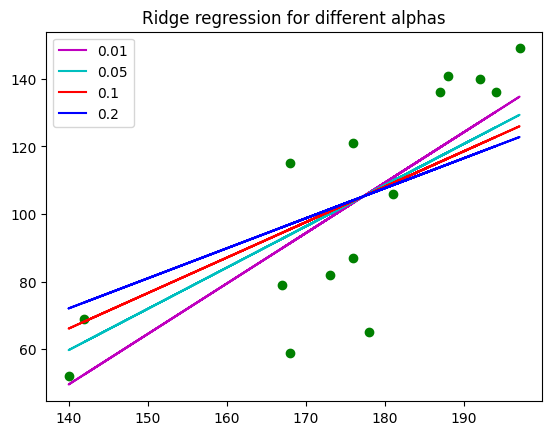

In [3]:
plt.scatter(heights, weights, color='g')

colors = ['m', 'c', 'r', 'b']

for i, (alpha, data) in enumerate(results.items()):
    plt.plot(heights, x @ data['coef'], color=colors[i], label=alpha)

plt.title("Ridge regression for different alphas")
plt.legend()
plt.show()

## 2. Implement based on the Ridge regression example, the Lasso regression.

Please implement the SGD method and compare the results with the sklearn Lasso regression results. 

In [4]:
def sgd(x, y, alpha=0.1, lr=1e-5, epochs=10):
    n_samples, n_features = x.shape
    w = np.zeros(n_features)

    for epoch in range(epochs):
        for i in np.random.permutation(n_samples):
            y_pred = x[i] @ w
            error = y[i] - y_pred

            grad_mse = -2 * x[i] * error
            grad_l1 = alpha * np.sign(w) / n_samples

            w -= lr * (grad_mse + grad_l1)

    return w

In [5]:
import numpy as np
from sklearn.linear_model import Lasso

x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(15,1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(15,1)

x = np.c_[np.ones((15,1)), x]

alpha = 0.1

w_sgd = sgd(x, y, alpha=alpha, lr=1e-5, epochs=10)

lasso = Lasso(alpha=alpha, fit_intercept=False)
lasso.fit(x, y)
w_sklearn = lasso.coef_


print("SGD weights:", w_sgd)
print("Sklearn Lasso weights:", w_sklearn)

SGD weights: [-0.00116232  0.6448246 ]
Sklearn Lasso weights: [-168.19471366    1.54607814]


## 3. Extend the Fisher's classifier

Please extend the targets of the ``iris_data`` variable and use it as the $y$.

Accuracy: 0.99


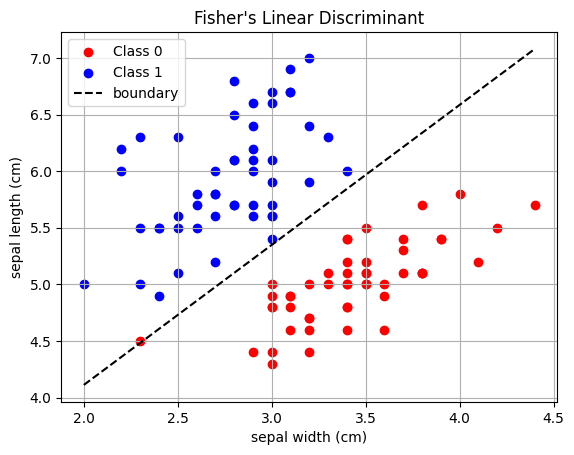

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris_data = load_iris()
iris_df = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)

x = iris_df[['sepal width (cm)', 'sepal length (cm)']].values
y = iris_data.target

# use only two classes
x = x[y != 2]
y = y[y != 2]

# split classes
x0 = x[y == 0]
x1 = x[y == 1]

m0 = np.mean(x0, axis=0)
m1 = np.mean(x1, axis=0)

S0 = (x0 - m0).T @ (x0 - m0)
S1 = (x1 - m1).T @ (x1 - m1)
Sw = S0 + S1

w = np.linalg.solve(Sw, (m1 - m0))

proj = x @ w
threshold = (m0 @ w + m1 @ w) / 2

y_pred = (proj >= threshold).astype(int)

accuracy = np.mean(y_pred == y)
print("Accuracy:", accuracy)


plt.scatter(x0[:, 0], x0[:, 1], color='red', label='Class 0')
plt.scatter(x1[:, 0], x1[:, 1], color='blue', label='Class 1')

# decision boundary
x_vals = np.linspace(x[:,0].min(), x[:,0].max(), 100)
y_vals = (threshold - w[0]*x_vals)/w[1]

plt.plot(x_vals, y_vals, 'k--', label='boundary')

plt.xlabel('sepal width (cm)')
plt.ylabel('sepal length (cm)')
plt.title("Fisher's Linear Discriminant")
plt.legend()
plt.grid()

plt.show()